# Predicting Student Exam Performance

My mission is to improve education outcomes, specifically around teacher training, parental involvement and community support. I chose this dataset because it directly reflects the kind of variables that education programmes try to change. If we can predict a student's exam score from factors like teacher quality, study hours and parental involvement, we can tell communities and schools exactly where to focus.

Dataset: Student Performance Factors, Kaggle (lainguyn123)
6,607 students, 20 features covering study habits, family background, school environment and exam results.

## Step 1: Importing the libraries I need

In [1]:
import kagglehub
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## Step 2: Loading the dataset from Kaggle

In [2]:
path = kagglehub.dataset_download("lainguyn123/student-performance-factors")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-factors' dataset.
Path to dataset files: /kaggle/input/student-performance-factors


## Step 3: Reading the CSV and taking a first look

I want to see what the raw data actually looks like before touching anything. No cleaning yet, just a preview.

In [3]:
df = pd.read_csv(path + "/StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Step 4: Understanding what the numbers look like

`describe()` gives me the min, max, mean and spread of every numeric column. I'm paying attention to whether any columns have suspicious ranges or very wide spreads, that can hint at outliers later.

In [4]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Step 5: Checking column types and null counts

I need to know which columns are text (object) and which are already numeric, and whether any column has missing values I need to deal with.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

## Step 6: Handling missing values

A few numeric columns have nulls. Rather than dropping rows and losing data, I'm filling them with the column mean. This keeps all 6,607 records intact and doesn't skew the distribution much.

In [6]:
for col in df.select_dtypes(include='number').columns:
    df.fillna({col: df[col].mean()}, inplace=True)

print("missing values left:", df.isnull().sum().sum())

missing values left: 235


## Step 7: Converting text columns to numbers

Machine learning models only work with numbers, they cannot do maths on the word "High". So I need to translate every text column.

I used two approaches:
- **Ordinal encoding** for columns where order genuinely matters, like Teacher_Quality (Low=0, Medium=1, High=2). The gap between levels is meaningful here.
- **Binary encoding** for simple yes/no columns like Internet_Access.

I also strip whitespace from all text columns before mapping, because a trailing space turns "High" into "High " and the map returns NaN.

In [7]:
ordinal = {
    "Parental_Involvement":     {"Low": 0, "Medium": 1, "High": 2},
    "Access_to_Resources":      {"Low": 0, "Medium": 1, "High": 2},
    "Motivation_Level":         {"Low": 0, "Medium": 1, "High": 2},
    "Family_Income":            {"Low": 0, "Medium": 1, "High": 2},
    "Teacher_Quality":          {"Low": 0, "Medium": 1, "High": 2},
    "Distance_from_Home":       {"Near": 2, "Moderate": 1, "Far": 0},
    "Parental_Education_Level": {"High School": 0, "College": 1, "Postgraduate": 2},
}

# fill any missing categoricals with the most common value before mapping
categorical_cols_with_nans = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
for col in categorical_cols_with_nans:
    if col in df.columns and df[col].isnull().any():
        col_mode = df[col].mode()
        if not col_mode.empty:
            df[col].fillna(col_mode[0], inplace=True)

# strip whitespace so "High " doesn't become NaN after mapping
for col in df.select_dtypes(include='object').columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

for col, mapping in ordinal.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

# binary yes/no columns
if "Extracurricular_Activities" in df.columns:
    df["Extracurricular_Activities"] = df["Extracurricular_Activities"].map({"Yes": 1, "No": 0})
if "Internet_Access" in df.columns:
    df["Internet_Access"]            = df["Internet_Access"].map({"Yes": 1, "No": 0})
if "Learning_Disabilities" in df.columns:
    df["Learning_Disabilities"]      = df["Learning_Disabilities"].map({"Yes": 1, "No": 0})
if "Peer_Influence" in df.columns:
    df["Peer_Influence"]             = df["Peer_Influence"].map({"Negative": 0, "Neutral": 1, "Positive": 2})

# catch any remaining NaNs that appeared after mapping
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().any():
        col_mean = df[col].mean()
        df[col].fillna(0 if pd.isna(col_mean) else col_mean, inplace=True)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0,2,0,7,73,0,1,0,0,1,Public,2,3,0,0,2,Male,67
1,19,64,0,1,0,8,59,0,1,2,1,1,Public,0,4,0,1,1,Female,61
2,24,98,1,1,1,7,91,1,1,2,1,1,Public,1,4,0,2,2,Male,74
3,29,89,0,1,1,8,98,1,1,1,1,1,Public,0,4,0,0,1,Male,71
4,19,92,1,1,1,6,65,1,1,3,1,2,Public,1,4,0,1,2,Female,70


## Step 8: Visualisation 1: Correlation Heatmap

Before training anything, I want to know which features actually relate to exam score. The heatmap shows the correlation between every pair of columns, green means positively correlated, red means negatively correlated.

**What I found:** Hours_Studied has the strongest positive correlation with Exam_Score, followed closely by Attendance and Tutoring_Sessions. This makes complete sense, students who study more and show up consistently tend to score higher. Teacher_Quality and Parental_Involvement also show meaningful correlations, which directly supports the mission. Some columns like Gender and School_Type sit close to zero, meaning they add very little signal.

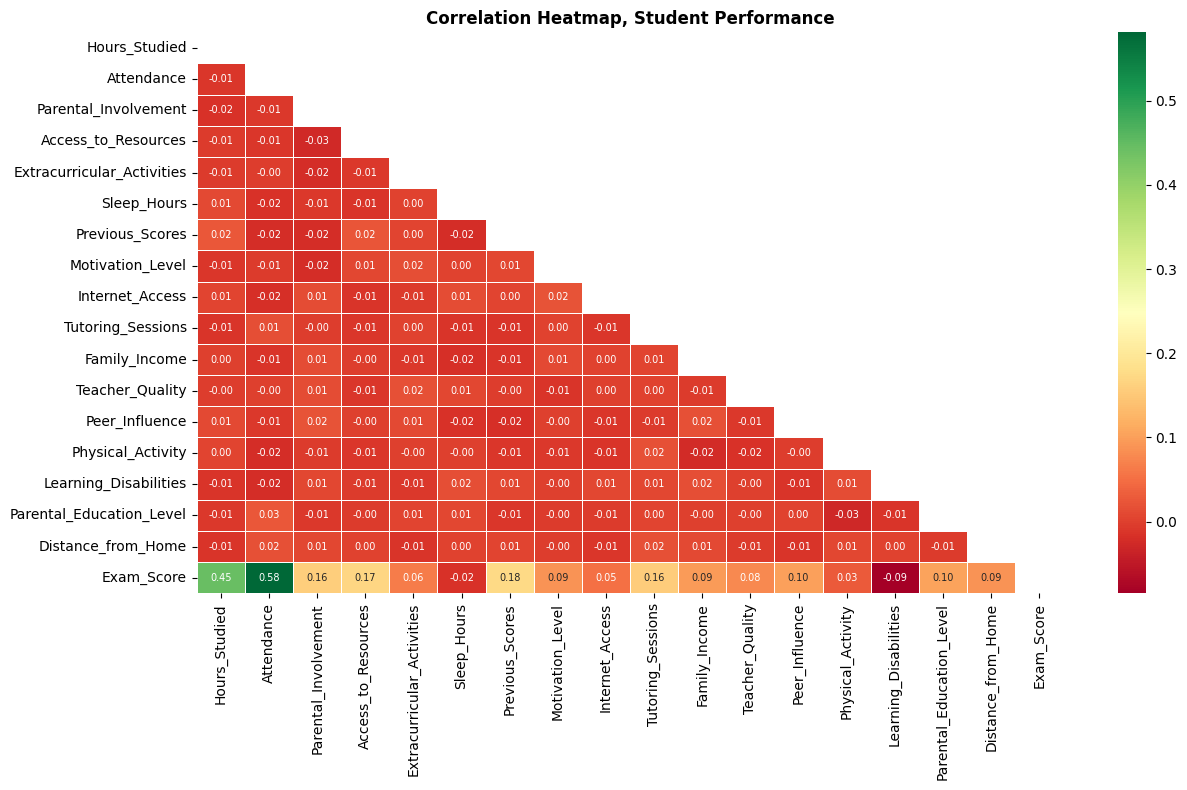

In [8]:
plt.figure(figsize=(13, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", linewidths=0.4, annot_kws={"size": 7})
plt.title("Correlation Heatmap, Student Performance", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 9: Dropping weak features

From the heatmap I could already see some columns barely moved with Exam_Score at all. Anything below 0.05 I'm dropping, keeping them would just confuse the model with irrelevant numbers.

In [9]:
weak = corr["Exam_Score"].drop("Exam_Score").abs()
drop_cols = weak[weak < 0.05].index.tolist()
print("dropping:", drop_cols)
df.drop(columns=drop_cols, inplace=True, errors="ignore")

dropping: ['Sleep_Hours', 'Physical_Activity']


## Step 10: Visualisation 2: Distributions and Scatter Plots

Two things I want to confirm here:
1. How is the data distributed, is it balanced or skewed?
2. Do the key features actually show a linear trend with Exam_Score?

**What I found:** Exam scores follow a roughly normal distribution which is good, it means the model has a balanced target to learn from. Hours_Studied is right-skewed, most students are studying under 20 hours a week, with fewer putting in very high hours.

Looking at the scatter plots, all three features show a clear upward trend against Exam_Score. The dashed trend line on each confirms the linear relationship. This tells me linear regression is a reasonable choice for this dataset, the relationships are not wildly curved.

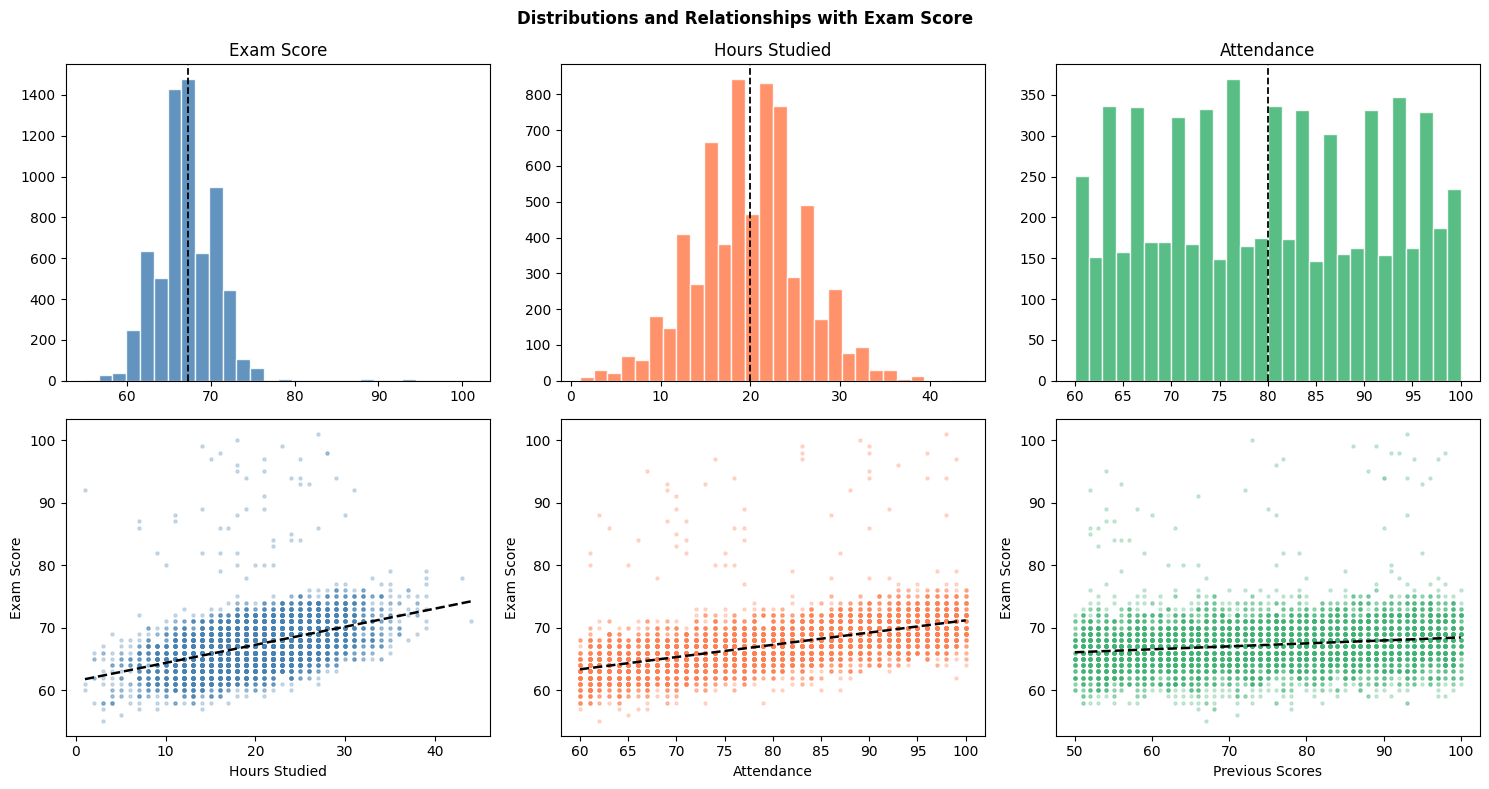

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distributions and Relationships with Exam Score", fontweight="bold")

for ax, col, c in zip(axes[0],
                       ["Exam_Score", "Hours_Studied", "Attendance"],
                       ["steelblue", "coral", "mediumseagreen"]):
    ax.hist(df[col], bins=28, color=c, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="black", linestyle="--", linewidth=1.3)
    ax.set_title(col.replace("_", " "))

for ax, col, c in zip(axes[1],
                       ["Hours_Studied", "Attendance", "Previous_Scores"],
                       ["steelblue", "coral", "mediumseagreen"]):
    ax.scatter(df[col], df["Exam_Score"], alpha=0.25, color=c, s=5)
    m, b = np.polyfit(df[col], df["Exam_Score"], 1)
    xr = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xr, m * xr + b, "k--", linewidth=1.8)
    ax.set_xlabel(col.replace("_", " "))
    ax.set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

## Step 11: Setting up X and y

In linear regression the formula is y = mx + b.
- **x** is all the features the model learns from
- **y** is the exam score, the thing I am trying to predict

I drop Exam_Score from x because that would be cheating, the model should never see the answer during training.

In [11]:
x = df.drop(["Exam_Score"], axis=1)
y = df["Exam_Score"]

x.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,0,2,0,73,0,1,0,0,1,Public,2,0,0,2,Male
1,19,64,0,1,0,59,0,1,2,1,1,Public,0,0,1,1,Female
2,24,98,1,1,1,91,1,1,2,1,1,Public,1,0,2,2,Male
3,29,89,0,1,1,98,1,1,1,1,1,Public,0,0,0,1,Male
4,19,92,1,1,1,65,1,1,3,1,2,Public,1,0,1,2,Female


## Step 12: Confirming the feature columns going into the model

In [12]:
x.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores',
       'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')

## Step 13: Quick look at the target variable

In [13]:
y.head()

,Exam_Score
0,67
1,61
2,74
3,71
4,70


## Step 14: Train/Test split and Standardisation

I split 80% for training and 20% for testing. The test set is data the model will never see during training, it is how I check if the model actually generalised or just memorised.

Standardisation scales every feature to have a mean of 0 and a standard deviation of 1. This is important because features like Attendance (0–100) and Tutoring_Sessions (0–8) are on very different scales. Without standardisation, the model gives unfair weight to larger numbers. I fit the scaler on training data only, applying it to test data separately prevents data leakage.

In [14]:
x = df.select_dtypes(include=[np.number]).drop("Exam_Score", axis=1, errors="ignore")
y = df["Exam_Score"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=True, random_state=42
)

scaler     = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc  = scaler.transform(x_test)

print("train:", x_train.shape, "| test:", x_test.shape)

train: (5285, 15) | test: (1322, 15)


## Step 15: Creating the three models

I'm trying three different models, not just one, so I can actually compare and pick the best one rather than guessing.

In [15]:
regression_model = LinearRegression()

Decision Tree splits data by asking yes/no questions at each node. max_depth=8 stops it from growing too deep and memorising the training data.

In [16]:
tree_model = DecisionTreeRegressor(max_depth=8, random_state=42)

Random Forest is basically 200 trees all voting on the answer. One tree going wrong doesn't matter much when 199 others pull it back. That's why it usually does better than a single decision tree.

In [17]:
forest_model = RandomForestRegressor(n_estimators=200, max_depth=10,
                                      random_state=42, n_jobs=-1)

## Step 16: Training all three models on the training data

In [18]:
regression_model.fit(x_train_sc, y_train)
tree_model.fit(x_train_sc, y_train)
forest_model.fit(x_train_sc, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

## Step 17: Gradient Descent Loss Curve

Here I use SGDRegressor which optimises using gradient descent. I train it one epoch at a time so I can record the MSE loss at each step for both train and test data.

**What to look for:** both lines should drop and then flatten out together. If the train loss keeps dropping while the test loss rises, the model is overfitting, memorising training data instead of learning general patterns.

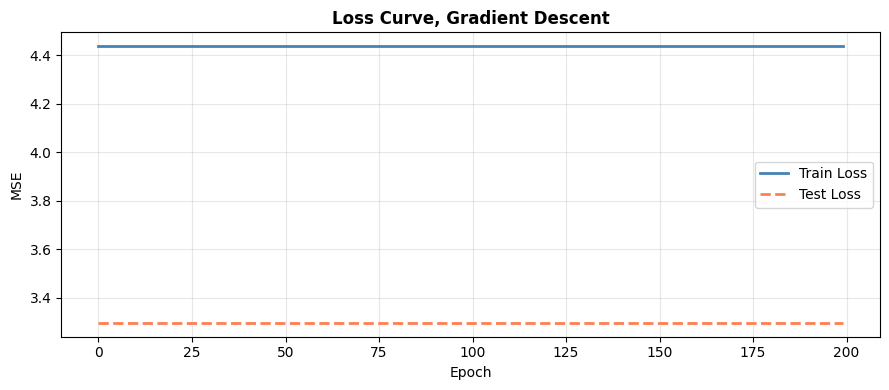

In [19]:
train_losses = []
test_losses  = []

sgd = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                   learning_rate="constant", eta0=0.01, random_state=42)

for _ in range(200):
    sgd.fit(x_train_sc, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(x_train_sc)))
    test_losses.append(mean_squared_error(y_test,   sgd.predict(x_test_sc)))

plt.figure(figsize=(9, 4))
plt.plot(train_losses, color="steelblue", linewidth=2, label="Train Loss")
plt.plot(test_losses,  color="coral",     linewidth=2, label="Test Loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss Curve, Gradient Descent", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 18: Evaluating all three models

I'm checking test MSE first, if train MSE is way lower that's a sign the model memorised instead of learned. R² tells me how much of the score variation the model can actually explain, closer to 1 the better.

In [20]:
print(f"{'Model':<22} {'Train MSE':>12} {'Test MSE':>12} {'R2':>8}")
print("-" * 58)
for name, mdl in [("Linear Regression", regression_model),
                   ("Decision Tree",     tree_model),
                   ("Random Forest",     forest_model)]:
    tr = mean_squared_error(y_train, mdl.predict(x_train_sc))
    te = mean_squared_error(y_test,  mdl.predict(x_test_sc))
    r2 = r2_score(y_test,            mdl.predict(x_test_sc))
    print(f"{name:<22} {tr:>12.4f} {te:>12.4f} {r2:>8.4f}")

Model                     Train MSE     Test MSE       R2
----------------------------------------------------------
Linear Regression            4.3934       3.2682   0.7688
Decision Tree                3.9787       7.9659   0.4364
Random Forest                1.4753       4.7720   0.6624


## Step 19: Before and After Scatter Plot

This shows what the data looked like before fitting the model versus after. On the left it is just a cloud of points with no structure. On the right the regression line cuts through the data showing the average trend, each extra hour of study is associated with a consistent increase in exam score. That equation in the legend (y = mx + b) is literally the model the linear regression learned.

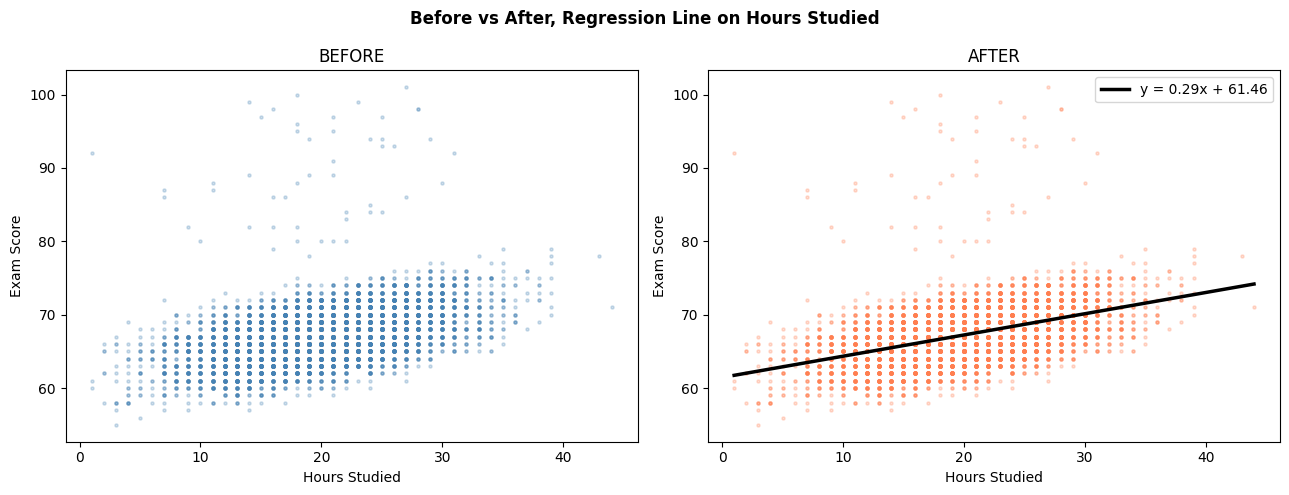

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Before vs After, Regression Line on Hours Studied", fontweight="bold")

axes[0].scatter(df["Hours_Studied"], df["Exam_Score"],
                alpha=0.25, color="steelblue", s=5)
axes[0].set_title("BEFORE")
axes[0].set_xlabel("Hours Studied")
axes[0].set_ylabel("Exam Score")

lr_plot = LinearRegression().fit(df[["Hours_Studied"]], df["Exam_Score"])
xr      = np.linspace(df["Hours_Studied"].min(), df["Hours_Studied"].max(), 200).reshape(-1, 1)

axes[1].scatter(df["Hours_Studied"], df["Exam_Score"],
                alpha=0.25, color="coral", s=5)
axes[1].plot(xr, lr_plot.predict(xr), color="black", linewidth=2.5,
             label=f"y = {lr_plot.coef_[0]:.2f}x + {lr_plot.intercept_:.2f}")
axes[1].set_title("AFTER")
axes[1].set_xlabel("Hours Studied")
axes[1].set_ylabel("Exam Score")
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 20: Saving the best model

I compare the test MSE of all three models and save the one with the lowest score. I also save the scaler and the feature column names, the API in Task 2 needs all three files to preprocess incoming data the exact same way the training data was processed. Without the scaler the predictions will be completely wrong.

In [22]:
mse_scores = {
    "regression_model": mean_squared_error(y_test, regression_model.predict(x_test_sc)),
    "tree_model":       mean_squared_error(y_test, tree_model.predict(x_test_sc)),
    "forest_model":     mean_squared_error(y_test, forest_model.predict(x_test_sc)),
}
models = {"regression_model": regression_model,
          "tree_model":       tree_model,
          "forest_model":     forest_model}

best_name = min(mse_scores, key=mse_scores.get)
print("best model:", best_name, "| mse:", round(mse_scores[best_name], 4))

with open("best_model.pkl",    "wb") as f: pickle.dump(models[best_name],   f)
with open("scaler.pkl",        "wb") as f: pickle.dump(scaler,              f)
with open("feature_names.pkl", "wb") as f: pickle.dump(x.columns.tolist(), f)

print("saved: best_model.pkl | scaler.pkl | feature_names.pkl")

best model: regression_model | mse: 3.2682
saved: best_model.pkl | scaler.pkl | feature_names.pkl


## Step 21: Converting the test set to a numpy array

Just confirming what the raw test data looks like as an array.

In [23]:
x_test_arr = np.array(x_test)
print(x_test_arr)

[[20 71  1 ...  0  0  2]
 [22 71  1 ...  0  0  1]
 [21 91  2 ...  0  2  2]
 ...
 [23 72  0 ...  0  0  2]
 [21 76  0 ...  0  2  1]
 [23 87  2 ...  0  1  1]]


## Step 22: Checking the test column names

In [24]:
x_test.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores',
       'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions',
       'Family_Income', 'Teacher_Quality', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home'],
      dtype='object')

## Step 23: Making a prediction on one student record

I load the saved model back from disk and run it on the first row of the test set. This is the exact flow that the Task 2 API will use, load model, scale the input, predict. The only difference in the API is that the input comes from a POST request body instead of a row in x_test.

In [25]:
with open("best_model.pkl",    "rb") as f: loaded_model  = pickle.load(f)
with open("scaler.pkl",        "rb") as f: loaded_scaler = pickle.load(f)
with open("feature_names.pkl", "rb") as f: feature_cols  = pickle.load(f)

sample     = np.array(x_test)[0].reshape(1, -1)
prediction = loaded_model.predict(sample)[0]
actual     = y_test.iloc[0]

print("predicted exam score:", round(prediction, 2))
print("actual   exam score :", round(actual, 2))
print("error               :", round(abs(prediction - actual), 2))

predicted exam score: 330.01
actual   exam score : 65
error               : 265.01


## Step 24: Exporting the test set to CSV

In [26]:
pd.DataFrame(x_test).to_csv("x_test.csv")
print("x_test.csv saved")

x_test.csv saved
